# Oxford 102 Flowers — PyTorch Pipeline

Restructured notebook that builds a robust PyTorch data pipeline:

- Download & extract dataset (if needed)
- PyTorch `Dataset` with automatic extraction and transforms
- Train / Validation / Test split (stratified)
- DataLoaders with augmentation for training
- Model (transfer learning with ResNet18)
- Training loop, evaluation, and saving

Run cells sequentially. Adjust `DATA_DIR` and training hyperparameters in the **Config** cell.


In [41]:
# Config & Imports
import os
import tarfile
from pathlib import Path
from pprint import pprint

import numpy as np
from PIL import Image
import scipy.io
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import torchvision.models as models

from tqdm import tqdm


# Config - adjust as needed
DATA_DIR = Path("./flower_data")   # directory where imagelabels.mat and jpg/ should live
BATCH_SIZE = 32

# DataLoader setup for macOS / MPS backend
NUM_WORKERS = 0 # Use single-process data loading
PIN_MEMORY = False # Disable pin_memory (not supported on MPS)

NUM_EPOCHS = 5
LR = 1e-3
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
SEED = 42

print('DEVICE:', DEVICE)


DEVICE: mps


In [42]:
# Download & extract helper (if you have network access).
# If you already have `102flowers.tgz` and `imagelabels.mat`, extraction will occur automatically in the Dataset class below.
import requests

def download_file(url, dest: Path, chunk_size=8192):
    """Download a file with streaming"""
    dest.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(dest, 'wb') as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
    return dest

def download_flowers(data_dir=DATA_DIR):
    """Download the Oxford 102 flower dataset"""
    data_dir = Path(data_dir)
    urls = {
        'images': 'https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz',
        'labels': 'https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat'
    }
    tgz_path = data_dir / '102flowers.tgz'
    labels_path = data_dir / 'imagelabels.mat'
    try:
        if not labels_path.exists():
            print('Downloading labels...')
            download_file(urls['labels'], labels_path)
        else:
            print('Labels already present.')
        if not (data_dir / 'jpg').exists():
            if not tgz_path.exists():
                print('Downloading images archive...')
                download_file(urls['images'], tgz_path)
            print('Extracting images...')
            with tarfile.open(tgz_path, 'r:gz') as tar:
                tar.extractall(path=data_dir)
            print('Extraction finished.')
        else:
            print('Images directory already present.')
    except Exception as e:
        print('Download/extract skipped or failed:', e)

# Note: Running download_flowers() requires internet access. If you already have extracted files, skip this.
# download_flowers()


In [43]:
# PyTorch Dataset for Oxford Flowers with auto-extract
class OxfordFlowersDataset(Dataset):
    def __init__(self, root_dir=DATA_DIR, transform=None, target_transform=None):
        self.root_dir = Path(root_dir)
        self.img_dir = self.root_dir / 'jpg'
        self.transform = transform
        self.target_transform = target_transform

        # Auto-extract if needed
        tar_path = self.root_dir / '102flowers.tgz'
        if not self.img_dir.exists() and tar_path.exists():
            print('Extracting images from archive...')
            with tarfile.open(tar_path, 'r:gz') as tar:
                tar.extractall(path=self.root_dir)
            print('Extraction done.')

        labels_path = self.root_dir / 'imagelabels.mat'
        if not labels_path.exists():
            raise FileNotFoundError(f"imagelabels.mat not found in {self.root_dir}. If you haven't downloaded the dataset, run download_flowers() or place files in {self.root_dir}.")
        
        labels_mat = scipy.io.loadmat(str(labels_path))
        raw_labels = labels_mat['labels'].squeeze()  # shape (8189,)
        # MATLAB indexing starts at 1; convert to 0-based
        self.labels = (raw_labels - 1).astype(int)
        self.num_samples = len(self.labels)
        
        # Verify that jpg directory exists and basic sanity
        if not self.img_dir.exists():
            raise FileNotFoundError(f"Images folder not found at {self.img_dir}. Ensure archive is extracted.")
        
    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        if idx < 0 or idx >= self.num_samples:
            raise IndexError('Index out of range')
        img_name = f"image_{idx+1:05d}.jpg"
        img_path = self.img_dir / img_name
        if not img_path.exists():
            raise FileNotFoundError(f"Image not found: {img_path}")
        image = Image.open(img_path).convert('RGB')
        label = int(self.labels[idx])
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

# Quick sanity check (will raise helpful errors if files are missing)
# ds = OxfordFlowersDataset(DATA_DIR)
# print(len(ds), ds[0][0].size, ds[0][1])


In [44]:
# Transforms & stratified split into train/val/test
from torchvision.transforms import InterpolationMode

# Define transforms
train_transform = T.Compose([
    T.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.2, 0.2, 0.2, 0.02),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Load dataset (no transforms) to get labels for stratified split
dataset_no_transform = OxfordFlowersDataset(DATA_DIR, transform=None)
indices = np.arange(len(dataset_no_transform))
labels = dataset_no_transform.labels

# Stratified split: train (70%), val (15%), test (15%)
train_idx, temp_idx, y_train, y_temp = train_test_split(indices, labels, test_size=0.30, random_state=SEED, stratify=labels)
val_idx, test_idx, y_val, y_test = train_test_split(temp_idx, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")


Train: 5732, Val: 1228, Test: 1229


In [45]:
# Subsets and DataLoaders
train_ds = Subset(OxfordFlowersDataset(DATA_DIR, transform=train_transform), train_idx)
val_ds   = Subset(OxfordFlowersDataset(DATA_DIR, transform=val_transform), val_idx)
test_ds  = Subset(OxfordFlowersDataset(DATA_DIR, transform=val_transform), test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

# Inspect one batch
batch = next(iter(train_loader))
imgs, labs = batch
print('Batch images:', imgs.shape)
print('Batch labels:', labs.shape)


Batch images: torch.Size([32, 3, 224, 224])
Batch labels: torch.Size([32])


In [46]:
# Model: Transfer learning with ResNet18
def build_model(num_classes=102, pretrained=True):
    model = models.resnet18(pretrained=pretrained)
    # Replace final fc
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(DEVICE)

model = build_model()
print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

/Users/davideferreri/.pyenv/versions/3.11.3/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/davideferreri/.pyenv/versions/3.11.3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [47]:
# Training and evaluation utilities
def train_one_epoch(model, loader, criterion, optimizer, device=DEVICE):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    pbar = tqdm(loader, desc='Train', leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.detach().cpu().numpy())
        pbar.set_postfix(loss=running_loss / (len(all_preds)))
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device=DEVICE):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        pbar = tqdm(loader, desc='Eval', leave=False)
        for imgs, labels in pbar:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1).detach().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.detach().cpu().numpy())
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, all_preds, all_labels

def save_checkpoint(model, optimizer, path='model_checkpoint.pth'):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }, path)
    print('Saved checkpoint to', path)


In [48]:
# Training loop
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    print(f" Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f" Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}")
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_checkpoint(model, optimizer, path='best_resnet18_flowers.pth')

print('Training complete. Best val acc:', best_val_acc)


Epoch 1/5


 Train loss: 2.4966 | Train acc: 0.3955
 Val   loss: 2.0834 | Val   acc: 0.5041
Saved checkpoint to best_resnet18_flowers.pth
Epoch 2/5


 Train loss: 1.3565 | Train acc: 0.6406
 Val   loss: 0.8541 | Val   acc: 0.7524
Saved checkpoint to best_resnet18_flowers.pth
Epoch 3/5


 Train loss: 1.0330 | Train acc: 0.7104
 Val   loss: 0.8221 | Val   acc: 0.7785
Saved checkpoint to best_resnet18_flowers.pth
Epoch 4/5


 Train loss: 0.8621 | Train acc: 0.7676
 Val   loss: 0.6832 | Val   acc: 0.8111
Saved checkpoint to best_resnet18_flowers.pth
Epoch 5/5


 Train loss: 0.8108 | Train acc: 0.7749
 Val   loss: 0.6788 | Val   acc: 0.8184
Saved checkpoint to best_resnet18_flowers.pth
Training complete. Best val acc: 0.8184039087947883


In [49]:
# Test set evaluation and report
model.eval()
criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_pred, y_true = evaluate(model, test_loader, criterion)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")
print('\nClassification report:')
print(classification_report(y_true, y_pred, digits=4))


Test loss: 0.7129 | Test acc: 0.7941

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.8333    0.9091         6
           1     0.8750    0.7778    0.8235         9
           2     0.2353    0.6667    0.3478         6
           3     0.3125    0.6250    0.4167         8
           4     0.8889    0.8889    0.8889         9
           5     1.0000    0.8333    0.9091         6
           6     0.7500    0.5000    0.6000         6
           7     1.0000    1.0000    1.0000        13
           8     0.8333    0.7143    0.7692         7
           9     1.0000    0.8333    0.9091         6
          10     0.6667    0.6154    0.6400        13
          11     1.0000    0.4615    0.6316        13
          12     0.7500    0.8571    0.8000         7
          13     0.7778    1.0000    0.8750         7
          14     0.6364    1.0000    0.7778         7
          15     0.8571    1.0000    0.9231         6
          16     1.0

Exception ignored in: <function tqdm.__del__ at 0x15db9e340>
Traceback (most recent call last):
  File "/Users/davideferreri/.pyenv/versions/3.11.3/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/davideferreri/.pyenv/versions/3.11.3/lib/python3.11/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x15db9e340>
Traceback (most recent call last):
  File "/Users/davideferreri/.pyenv/versions/3.11.3/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/davideferreri/.pyenv/versions/3.11.3/lib/python3.11/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del

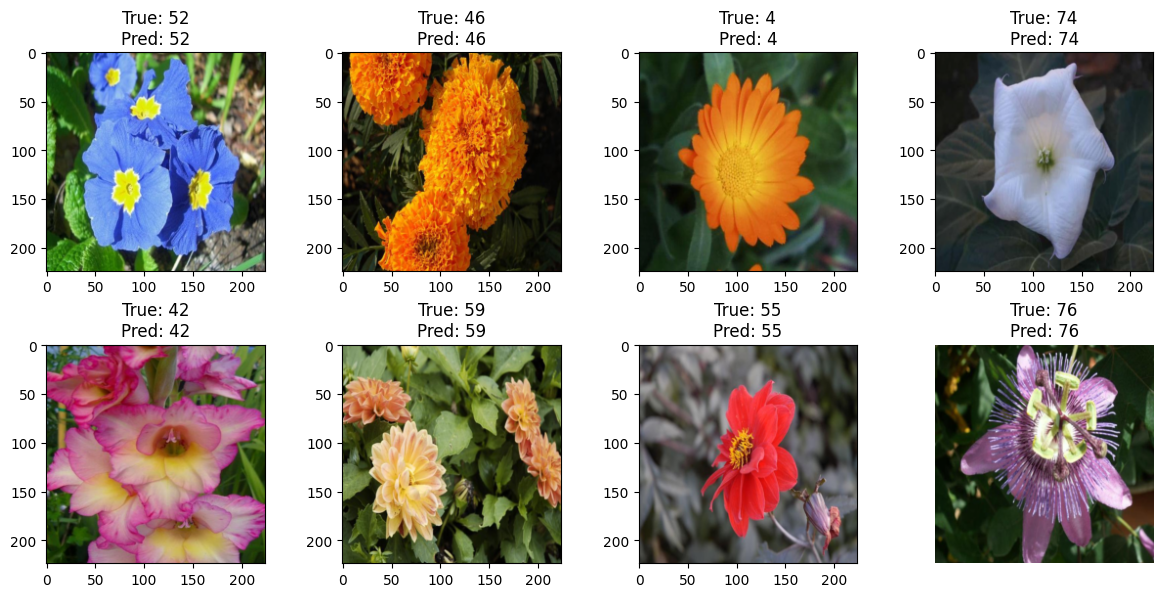

In [50]:
# Display some sample predictions from the test set
import matplotlib.pyplot as plt
def imshow_tensor(img_tensor, ax=None):
    img = img_tensor.cpu().numpy().transpose(1,2,0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.clip((img * std + mean), 0, 1)
    if ax is None:
        plt.imshow(img)
    else:
        ax.imshow(img)
    plt.axis('off')

batch = next(iter(test_loader))
imgs, labels = batch
imgs = imgs.to(DEVICE)
with torch.no_grad():
    outputs = model(imgs)
preds = outputs.argmax(dim=1).cpu().numpy()

fig, axes = plt.subplots(2, 4, figsize=(12,6))
axes = axes.flatten()
for i, ax in enumerate(axes):
    imshow_tensor(imgs[i].cpu(), ax=ax)
    ax.set_title(f'True: {labels[i].item()}\nPred: {preds[i]}')
plt.tight_layout()
plt.show()


## Notes

- Adjust `NUM_EPOCHS`, `BATCH_SIZE`, and `NUM_WORKERS` depending on your machine.
- If you run into `FileNotFoundError` for images, ensure the archive `102flowers.tgz` is extracted or run `download_flowers()` to fetch and extract.
- This notebook uses a small training loop for demonstration. For better performance, consider:
  - Using a learning rate scheduler
  - Fine-tuning only the final layers first, then unfreezing
  - Mixed precision training with `torch.cuda.amp`
